## Import libraries

In [5]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras import layers
from tabulate import tabulate
from pydantic import BaseModel
from typing import Dict, List
import joblib
import json
import time
import os

MODEL_DIR  = "models"
MODELS_JSON = "models.json"
CICEVSE_SUBDIR = f"{MODEL_DIR}/cicevse"
CICIDS_SUBDIR  = f"{MODEL_DIR}/cicids"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CICEVSE_SUBDIR, exist_ok=True)
os.makedirs(CICIDS_SUBDIR, exist_ok=True)

def _load_registry() -> dict:
    if os.path.exists(MODELS_JSON):
        with open(MODELS_JSON) as f:
            return json.load(f)
    return {}

def _save_registry(registry: dict):
    with open(MODELS_JSON, "w") as f:
        json.dump(registry, f, indent=2)

In [7]:
import shutil

def _migrate_models_to_subdirs():
    """One-time migration: move flat models/* files into models/cicevse/ and update registry."""
    registry = _load_registry()
    if not registry:
        return

    needs_migration = any(
        not entry.get("model_path", "").startswith(f"{CICEVSE_SUBDIR}/")
        for entry in registry.values()
    )
    if not needs_migration:
        return

    new_registry = {}
    for old_key, entry in registry.items():
        old_path = entry["model_path"]
        filename = os.path.basename(old_path)
        new_path = f"{CICEVSE_SUBDIR}/{filename}"

        if os.path.exists(old_path) and not os.path.exists(new_path):
            shutil.move(old_path, new_path)
        elif os.path.exists(old_path) and os.path.exists(new_path):
            os.remove(old_path)

        new_key = f"[CICEVSE] {old_key}" if not old_key.startswith("[") else old_key

        new_entry = dict(entry)
        new_entry["model_path"] = new_path
        new_entry["dataset"] = "cicevse"
        new_registry[new_key] = new_entry

    _save_registry(new_registry)
    print(f"Migrated {len(new_registry)} model(s) to {CICEVSE_SUBDIR}/")

_migrate_models_to_subdirs()

In [8]:
# Configure TensorFlow to use GPU > TPU > CPU (whichever is available)

def configure_tf_device():
    # Suppress verbose TF/CUDA logs before device selection
    os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

    # 1. Try TPU
    try:
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        print(f"TPU detected — using TPUStrategy ({strategy.num_replicas_in_sync} cores)")
        return strategy, "TPU"
    except (ValueError, tf.errors.NotFoundError):
        pass

    # 2. Try GPU
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            strategy = tf.distribute.MirroredStrategy()
            print(f"GPU detected — using MirroredStrategy ({len(gpus)} GPU(s): "
                  f"{[g.name for g in gpus]})")
            return strategy, "GPU"
        except RuntimeError as e:
            print(f"GPU found but could not be configured: {e}")

    # 3. Fallback to CPU
    strategy = tf.distribute.get_strategy()   # default (no-op) strategy
    print("No GPU/TPU found — falling back to CPU")
    return strategy, "CPU"

tf_strategy, tf_device = configure_tf_device()


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
GPU detected — using MirroredStrategy (1 GPU(s): ['/physical_device:GPU:0'])


In [9]:
class ModelResult(BaseModel):
    model_name: str
    training_time_s: float
    inference_time_ms: float       # per-sample inference latency
    accuracy: float
    precision: float               # weighted
    recall: float                  # weighted
    f1_score: float                # weighted
    accuracy_std: float = 0.0
    precision_std: float = 0.0
    recall_std: float = 0.0
    f1_score_std: float = 0.0
    confusion_matrix: List[List[int]]
    per_class_metrics: Dict[str, Dict[str, float]]  # class label -> {precision, recall, f1-score, support}

    def to_summary_dict(self) -> dict:
        """Flat dict suitable for a summary comparison table row."""
        return {
            'Model':                   self.model_name,
            'Accuracy (%)':            f"{self.accuracy*100:.3f} ± {self.accuracy_std*100:.3f}",
            'Precision (%)':           f"{self.precision*100:.3f} ± {self.precision_std*100:.3f}",
            'Recall (%)':              f"{self.recall*100:.3f} ± {self.recall_std*100:.3f}",
            'F1-Score (%)':            f"{self.f1_score*100:.3f} ± {self.f1_score_std*100:.3f}",
            'Train Time (s)':          round(self.training_time_s,  3),
            'Infer. Time (ms/sample)': round(self.inference_time_ms, 4),
        }

### Load CICEVSE2024 data

In [10]:
# Read the dataset
df_cicevse_2024 = pd.read_csv('CICEVSE2024_12classes_kmeans_rule_sampled1000.csv')

In [11]:
df_cicevse_2024

,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,...,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,Label
0,0.0,0.396825,0.500000,0.714286,0.135668,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
1,0.0,0.476190,0.500000,0.714286,0.347005,0.453333,0.176471,0.111111,0.001221,0.020408,...,0.230769,1.000000,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
2,0.0,0.317460,0.833333,0.857143,0.703655,0.346667,0.705882,0.777778,0.008286,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1
3,0.0,0.539683,0.500000,0.714286,0.942000,0.400000,0.705882,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,10
4,0.0,0.396825,0.500000,0.714286,0.152590,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35936,0.0,0.396825,0.500000,0.714286,0.660441,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
35937,0.0,0.539683,0.500000,0.714286,0.929381,0.400000,0.764706,0.777778,0.145495,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,2
35938,0.0,0.317460,0.833333,0.857143,0.690272,0.346667,0.705882,0.777778,0.045853,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,3
35939,0.0,0.539683,0.500000,0.714286,0.799344,0.400000,0.705882,0.777778,0.084077,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1


In [12]:
# print the class distribution of the last column
df_cicevse_2024['Label'].value_counts()

Label
7     7696
3     5807
1     4739
8     3690
2     3421
5     3110
11    2787
10    1898
9     1577
6     1044
4       90
0       82
Name: count, dtype: int64

| Name                                                   | Original Number of Samples | Reduced Subset | Label |
|--------------------------------------------------------|----------------------------|----------------|-------|
| Class 2 DoS: TCP floods                                | 721044                     | 7696           | 7     |
| Class 1 Discovery: Stealth SYN scanning                | 530946                     | 5807           | 3     |
| Class 1 Discovery: Port scanning                       | 426659                     | 4739           | 1     |
| Class 1 Discovery: Service detection                   | 292856                     | 3690           | 8     |
| Class 2 DoS: Identity rotation and rotation flood      | 262185                     | 3421           | 2    |
| Class 3 Reconnaissance: Vulnerability scan             | 231367                     | 3110           | 5     |
| Class 3 Reconnaissance: OS fingerprinting              | 140273                     | 2787           | 11    |
| Class 3 Reconnaissance: Aggressive scan                | 102522                     | 1898           | 10    |
| Class 2 DoS: UDP flood                                 | 32475                      | 1577           | 9     |
| Class 2 DoS: Slow request starvation                   | 4201                       | 1044           | 6     |
| Class 2 DoS: ICMP flood or fragmentation               | 90                         | 90             | 4     |
| Class 0 Normal                                         | 82                         | 82             | 0     |

/tmp/ipykernel_7623/3854627974.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right')


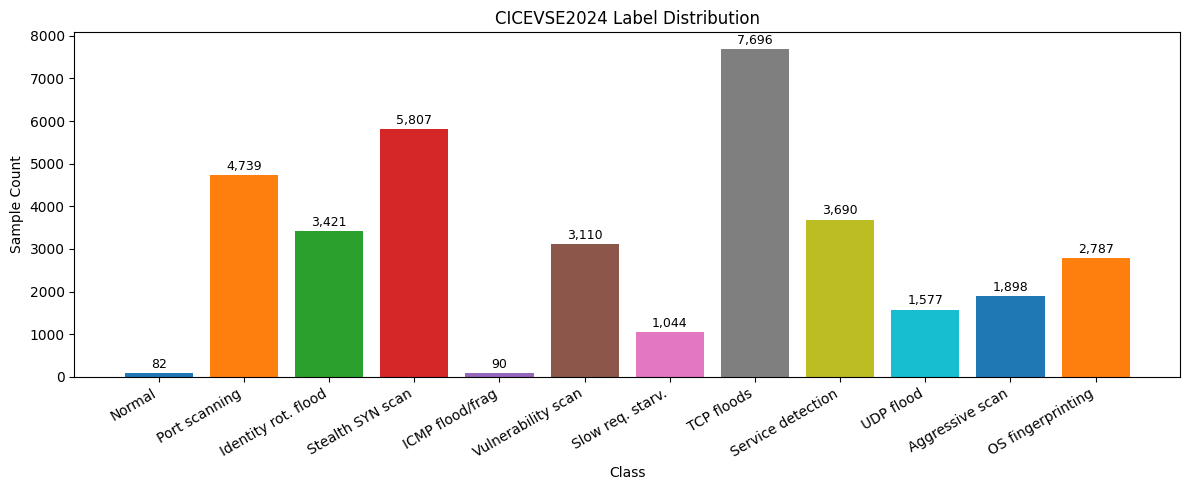

In [13]:
# Bar plot of label value counts with class names
label_names_cicevse = {
    0: 'Normal',
    1: 'Port scanning',
    2: 'Identity rot. flood',
    3: 'Stealth SYN scan',
    4: 'ICMP flood/frag',
    5: 'Vulnerability scan',
    6: 'Slow req. starv.',
    7: 'TCP floods',
    8: 'Service detection',
    9: 'UDP flood',
    10: 'Aggressive scan',
    11: 'OS fingerprinting',
}

counts = df_cicevse_2024['Label'].value_counts().sort_index()
labels = [label_names_cicevse[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, counts.values, color=sns.color_palette('tab10', len(counts)))
ax.set_xlabel('Class')
ax.set_ylabel('Sample Count')
ax.set_title('CICEVSE2024 Label Distribution')
ax.set_xticklabels(labels, rotation=30, ha='right')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Load CICIDS2017 data

In [14]:
# Read the CICIDS2017 dataset
df_cicids_2017 = pd.read_csv('CICIDS2017_0.01.csv')

In [15]:
df_cicids_2017

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,-0.277252,-0.008485,-0.009418,-0.054965,-0.007142,-0.289465,-0.310140,-0.312760,-0.245069,-0.447423,...,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,BENIGN
1,-0.439347,-0.009819,-0.010421,-0.054965,-0.007142,-0.289465,-0.310140,-0.312760,-0.245069,-0.447423,...,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,DoS
2,-0.439347,-0.009819,-0.010421,-0.054965,-0.007142,-0.289465,-0.310140,-0.312760,-0.245069,-0.447423,...,0.002545,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,BENIGN
3,-0.439341,-0.009819,-0.008416,-0.049562,-0.007104,-0.251818,0.137329,-0.167670,-0.245069,-0.425331,...,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,BENIGN
4,-0.439345,-0.011153,-0.009418,-0.054765,-0.007139,-0.286676,-0.276994,-0.302013,-0.245069,-0.444340,...,0.002549,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,PortScan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28302,-0.439345,-0.011153,-0.009418,-0.054965,-0.007142,-0.289465,-0.310140,-0.312760,-0.245069,-0.447423,...,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,BENIGN
28303,-0.439339,-0.009819,-0.008416,-0.046760,-0.006879,-0.232297,0.369350,-0.092438,-0.245069,-0.294831,...,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,BENIGN
28304,-0.439347,-0.009819,-0.010421,-0.054965,-0.007142,-0.289465,-0.310140,-0.312760,-0.245069,-0.447423,...,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,DoS
28305,-0.439338,-0.009819,-0.008416,-0.037955,-0.007023,-0.170946,1.098559,0.144005,-0.245069,-0.378063,...,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,BENIGN


In [16]:
# print the class distribution of the last column
df_cicids_2017['Label'].value_counts()

Label
BENIGN        22750
DoS            3782
PortScan       1608
BruteForce      123
WebAttack        23
Bot              21
Name: count, dtype: int64

/tmp/ipykernel_7623/2388737226.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right')


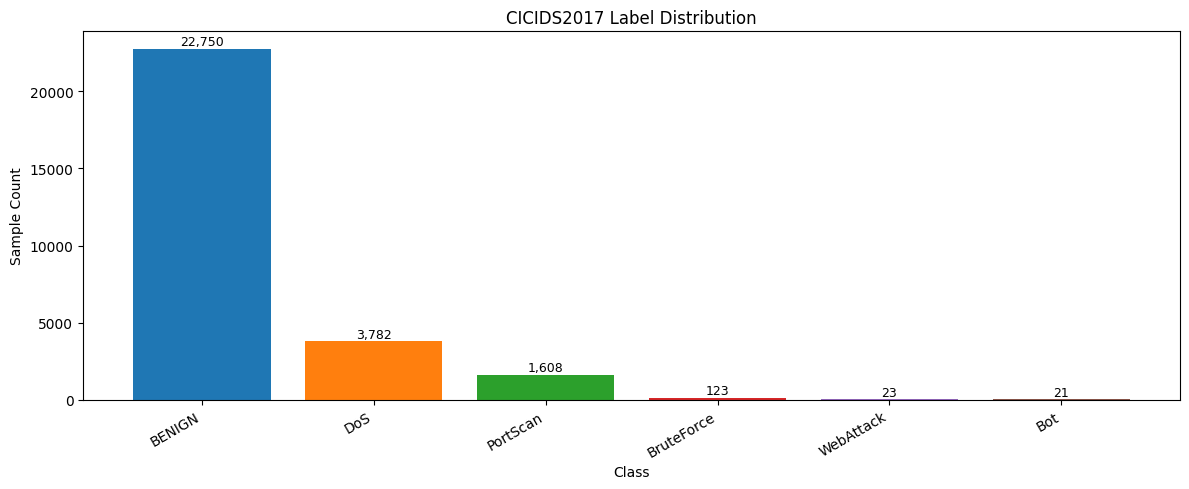

In [17]:
counts = df_cicids_2017['Label'].value_counts()
labels = [str(l) for l in counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, counts.values, color=sns.color_palette('tab10', len(counts)))
ax.set_xlabel('Class')
ax.set_ylabel('Sample Count')
ax.set_title('CICIDS2017 Label Distribution')
ax.set_xticklabels(labels, rotation=30, ha='right')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Data pre-processing (CICEVSE2024)

In [18]:
# Encode the dataset
labelencoder = LabelEncoder()
df_cicevse_2024.iloc[:, -1] = labelencoder.fit_transform(df_cicevse_2024.iloc[:, -1])

In [19]:
# min-max normalization
for column in df_cicevse_2024.columns[:-1]: # excluding the last column
    df_cicevse_2024[column] = (df_cicevse_2024[column] - df_cicevse_2024[column].min()) / (df_cicevse_2024[column].max() - df_cicevse_2024[column].min())

In [20]:
# address empty values
if df_cicevse_2024.isnull().values.any() or np.isinf(df_cicevse_2024).values.any():
    df_cicevse_2024.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cicevse_2024.fillna(0, inplace=True)

In [21]:
X_cicevse = df_cicevse_2024.drop(['Label'], axis=1)
y_cicevse = df_cicevse_2024.iloc[:, -1]

# 3-fold stratified cross-validation
cv_cicevse = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

### Data pre-processing (CICIDS2017)

In [22]:
# Encode string labels to integers
labelencoder_cicids = LabelEncoder()
df_cicids_2017['Label'] = labelencoder_cicids.fit_transform(df_cicids_2017['Label'])

In [23]:
# min-max normalization
for column in df_cicids_2017.columns[:-1]:
    col_range = df_cicids_2017[column].max() - df_cicids_2017[column].min()
    if col_range > 0:
        df_cicids_2017[column] = (df_cicids_2017[column] - df_cicids_2017[column].min()) / col_range
    else:
        df_cicids_2017[column] = 0

In [24]:
# address empty values
if df_cicids_2017.isnull().values.any() or np.isinf(df_cicids_2017.select_dtypes(include=[np.number])).values.any():
    df_cicids_2017.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cicids_2017.fillna(0, inplace=True)

In [25]:
X_cicids = df_cicids_2017.drop(['Label'], axis=1)
y_cicids = df_cicids_2017['Label']

# 3-fold stratified cross-validation
cv_cicids = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

### Reference Models from Literature

| Paper | Link | Models |
|-------|------|--------|
| Tree-based Intelligent Intrusion Detection System in Internet of Vehicles | [arXiv:1910.08635](https://arxiv.org/pdf/1910.08635) | Random Forest, Decision Tree, Extra Tree, XGBoost |
| MTH-IDS: A Multitiered Hybrid Intrusion Detection System for Internet of Vehicles | [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9443234) | Multi-SVM, KNN |
|A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles| [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9838780) | VGG16, VGG19|
|Deep Learning Approach for Intelligent Intrusion Detection System| [IEEE Xplore](https://ieeexplore.ieee.org/abstract/document/8681044)| DNN, LR|
| | | LightGBM|


In [26]:
def _per_class_from_conf_matrix(conf_matrix, labels):
    """Derive per-class precision/recall/f1 from a summed confusion matrix."""
    per_class = {}
    for i, lbl in enumerate(labels):
        tp = conf_matrix[i, i]
        fp = conf_matrix[:, i].sum() - tp
        fn = conf_matrix[i, :].sum() - tp
        support = conf_matrix[i, :].sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        per_class[str(lbl)] = {"precision": prec, "recall": rec, "f1-score": f1, "support": float(support)}
    return per_class


def train_xgboost(
    X, y, cv,
    model_name: str = "XGBoost (default)",
    model_path: str = f"{MODEL_DIR}/xgboost.json",
) -> ModelResult:
    """Train XGBoost with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = xgb.XGBClassifier()
        model.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = xgb.XGBClassifier(random_state=42)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = xgb.XGBClassifier(random_state=42)
        model.fit(X, y)
        model.save_model(model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


xgb_result = train_xgboost(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] XGBoost (default)", model_path=f"{CICEVSE_SUBDIR}/xgboost.json")
print(f"Done — {xgb_result.model_name}  |  Accuracy: {xgb_result.accuracy*100:.3f}% ± {xgb_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] XGBoost (default)...
  Fold 1: Accuracy=99.933%
  Fold 2: Training [CICEVSE] XGBoost (default)...
  Fold 2: Accuracy=99.900%
  Fold 3: Training [CICEVSE] XGBoost (default)...
  Fold 3: Accuracy=99.850%
Done — [CICEVSE] XGBoost (default)  |  Accuracy: 99.894% ± 0.034%


In [27]:
xgb_result_cicids = train_xgboost(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] XGBoost (default)", model_path=f"{CICIDS_SUBDIR}/xgboost.json")
print(f"Done — {xgb_result_cicids.model_name}  |  Accuracy: {xgb_result_cicids.accuracy*100:.3f}% ± {xgb_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] XGBoost (default)...
  Fold 1: Accuracy=99.714%
  Fold 2: Training [CICIDS] XGBoost (default)...
  Fold 2: Accuracy=99.724%
  Fold 3: Training [CICIDS] XGBoost (default)...
  Fold 3: Accuracy=99.650%
Done — [CICIDS] XGBoost (default)  |  Accuracy: 99.696% ± 0.033%


In [28]:
def train_random_forest(
    X, y, cv,
    model_name: str = "Random Forest",
    model_path: str = f"{MODEL_DIR}/random_forest.pkl",
) -> ModelResult:
    """Train Random Forest with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = RandomForestClassifier(random_state=42)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = RandomForestClassifier(random_state=42)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


rf_result = train_random_forest(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] Random Forest", model_path=f"{CICEVSE_SUBDIR}/random_forest.pkl")
print(f"Done — {rf_result.model_name}  |  Accuracy: {rf_result.accuracy*100:.3f}% ± {rf_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] Random Forest...
  Fold 1: Accuracy=99.883%
  Fold 2: Training [CICEVSE] Random Forest...
  Fold 2: Accuracy=99.900%
  Fold 3: Training [CICEVSE] Random Forest...
  Fold 3: Accuracy=99.775%
Done — [CICEVSE] Random Forest  |  Accuracy: 99.853% ± 0.056%


In [29]:
rf_result_cicids = train_random_forest(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] Random Forest", model_path=f"{CICIDS_SUBDIR}/random_forest.pkl")
print(f"Done — {rf_result_cicids.model_name}  |  Accuracy: {rf_result_cicids.accuracy*100:.3f}% ± {rf_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] Random Forest...
  Fold 1: Accuracy=99.565%
  Fold 2: Training [CICIDS] Random Forest...
  Fold 2: Accuracy=99.597%
  Fold 3: Training [CICIDS] Random Forest...
  Fold 3: Accuracy=99.438%
Done — [CICIDS] Random Forest  |  Accuracy: 99.534% ± 0.069%


In [30]:
def train_decision_tree(
    X, y, cv,
    model_name: str = "Decision Tree",
    model_path: str = f"{MODEL_DIR}/decision_tree.pkl",
) -> ModelResult:
    """Train Decision Tree with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = DecisionTreeClassifier(random_state=42)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = DecisionTreeClassifier(random_state=42)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


dt_result = train_decision_tree(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] Decision Tree", model_path=f"{CICEVSE_SUBDIR}/decision_tree.pkl")
print(f"Done — {dt_result.model_name}  |  Accuracy: {dt_result.accuracy*100:.3f}% ± {dt_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] Decision Tree...
  Fold 1: Accuracy=99.967%
  Fold 2: Training [CICEVSE] Decision Tree...
  Fold 2: Accuracy=99.967%
  Fold 3: Training [CICEVSE] Decision Tree...
  Fold 3: Accuracy=99.925%
Done — [CICEVSE] Decision Tree  |  Accuracy: 99.953% ± 0.020%


In [31]:
dt_result_cicids = train_decision_tree(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] Decision Tree", model_path=f"{CICIDS_SUBDIR}/decision_tree.pkl")
print(f"Done — {dt_result_cicids.model_name}  |  Accuracy: {dt_result_cicids.accuracy*100:.3f}% ± {dt_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] Decision Tree...
  Fold 1: Accuracy=99.343%
  Fold 2: Training [CICIDS] Decision Tree...
  Fold 2: Accuracy=99.470%
  Fold 3: Training [CICIDS] Decision Tree...
  Fold 3: Accuracy=99.449%
Done — [CICIDS] Decision Tree  |  Accuracy: 99.421% ± 0.056%


In [32]:
def train_extra_trees(
    X, y, cv,
    model_name: str = "Extra Trees",
    model_path: str = f"{MODEL_DIR}/extra_trees.pkl",
) -> ModelResult:
    """Train Extra Trees with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = ExtraTreesClassifier(random_state=42)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = ExtraTreesClassifier(random_state=42)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


et_result = train_extra_trees(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] Extra Trees", model_path=f"{CICEVSE_SUBDIR}/extra_trees.pkl")
print(f"Done — {et_result.model_name}  |  Accuracy: {et_result.accuracy*100:.3f}% ± {et_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] Extra Trees...
  Fold 1: Accuracy=99.775%
  Fold 2: Training [CICEVSE] Extra Trees...
  Fold 2: Accuracy=99.791%
  Fold 3: Training [CICEVSE] Extra Trees...
  Fold 3: Accuracy=99.624%
Done — [CICEVSE] Extra Trees  |  Accuracy: 99.730% ± 0.075%


In [33]:
et_result_cicids = train_extra_trees(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] Extra Trees", model_path=f"{CICIDS_SUBDIR}/extra_trees.pkl")
print(f"Done — {et_result_cicids.model_name}  |  Accuracy: {et_result_cicids.accuracy*100:.3f}% ± {et_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] Extra Trees...
  Fold 1: Accuracy=99.438%
  Fold 2: Training [CICIDS] Extra Trees...
  Fold 2: Accuracy=99.481%
  Fold 3: Training [CICIDS] Extra Trees...
  Fold 3: Accuracy=99.311%
Done — [CICIDS] Extra Trees  |  Accuracy: 99.410% ± 0.072%


In [34]:
def train_svm(
    X, y, cv,
    model_name: str = "Svm",
    model_path: str = f"{MODEL_DIR}/svm.pkl",
) -> ModelResult:
    """Train SVM with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = SVC(random_state=42)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = SVC(random_state=42)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


svm_result = train_svm(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] Multi-SVM", model_path=f"{CICEVSE_SUBDIR}/svm.pkl")
print(f"Done — {svm_result.model_name}  |  Accuracy: {svm_result.accuracy*100:.3f}% ± {svm_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] Multi-SVM...
  Fold 1: Accuracy=59.452%
  Fold 2: Training [CICEVSE] Multi-SVM...
  Fold 2: Accuracy=59.599%
  Fold 3: Training [CICEVSE] Multi-SVM...
  Fold 3: Accuracy=59.533%
Done — [CICEVSE] Multi-SVM  |  Accuracy: 59.528% ± 0.060%


In [35]:
svm_result_cicids = train_svm(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] Multi-SVM", model_path=f"{CICIDS_SUBDIR}/svm.pkl")
print(f"Done — {svm_result_cicids.model_name}  |  Accuracy: {svm_result_cicids.accuracy*100:.3f}% ± {svm_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] Multi-SVM...
  Fold 1: Accuracy=94.341%
  Fold 2: Training [CICIDS] Multi-SVM...
  Fold 2: Accuracy=94.479%
  Fold 3: Training [CICIDS] Multi-SVM...
  Fold 3: Accuracy=93.874%
Done — [CICIDS] Multi-SVM  |  Accuracy: 94.231% ± 0.259%


In [36]:
def train_knn(
    X, y, cv,
    model_name: str = "Knn",
    model_path: str = f"{MODEL_DIR}/knn.pkl",
) -> ModelResult:
    """Train KNN with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = KNeighborsClassifier()

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = KNeighborsClassifier()
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


knn_result = train_knn(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] KNN", model_path=f"{CICEVSE_SUBDIR}/knn.pkl")
print(f"Done — {knn_result.model_name}  |  Accuracy: {knn_result.accuracy*100:.3f}% ± {knn_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] KNN...
  Fold 1: Accuracy=60.487%
  Fold 2: Training [CICEVSE] KNN...
  Fold 2: Accuracy=60.634%
  Fold 3: Training [CICEVSE] KNN...
  Fold 3: Accuracy=60.109%
Done — [CICEVSE] KNN  |  Accuracy: 60.410% ± 0.222%


In [37]:
knn_result_cicids = train_knn(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] KNN", model_path=f"{CICIDS_SUBDIR}/knn.pkl")
print(f"Done — {knn_result_cicids.model_name}  |  Accuracy: {knn_result_cicids.accuracy*100:.3f}% ± {knn_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] KNN...
  Fold 1: Accuracy=98.516%
  Fold 2: Training [CICIDS] KNN...
  Fold 2: Accuracy=98.294%
  Fold 3: Training [CICIDS] KNN...
  Fold 3: Accuracy=98.357%
Done — [CICIDS] KNN  |  Accuracy: 98.389% ± 0.094%


In [38]:
def train_logistic_regression(
    X, y, cv,
    model_name: str = "Logistic Regression",
    model_path: str = f"{MODEL_DIR}/logistic_regression.pkl",
) -> ModelResult:
    """Train Logistic Regression with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = LogisticRegression(random_state=42, max_iter=1000)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


lr_result = train_logistic_regression(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] Logistic Regression", model_path=f"{CICEVSE_SUBDIR}/logistic_regression.pkl")
print(f"Done — {lr_result.model_name}  |  Accuracy: {lr_result.accuracy*100:.3f}% ± {lr_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] Logistic Regression...
  Fold 1: Accuracy=59.536%
  Fold 2: Training [CICEVSE] Logistic Regression...
  Fold 2: Accuracy=59.825%
  Fold 3: Training [CICEVSE] Logistic Regression...
  Fold 3: Accuracy=59.549%
Done — [CICEVSE] Logistic Regression  |  Accuracy: 59.637% ± 0.133%


In [39]:
lr_result_cicids = train_logistic_regression(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] Logistic Regression", model_path=f"{CICIDS_SUBDIR}/logistic_regression.pkl")
print(f"Done — {lr_result_cicids.model_name}  |  Accuracy: {lr_result_cicids.accuracy*100:.3f}% ± {lr_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] Logistic Regression...
  Fold 1: Accuracy=93.239%
  Fold 2: Training [CICIDS] Logistic Regression...
  Fold 2: Accuracy=93.387%
  Fold 3: Training [CICIDS] Logistic Regression...
  Fold 3: Accuracy=93.015%
Done — [CICIDS] Logistic Regression  |  Accuracy: 93.214% ± 0.153%


In [40]:
def train_dnn(
    X, y, cv,
    model_name: str = "DNN",
    model_path: str = f"{MODEL_DIR}/dnn.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """
    Deep Neural Network per the paper architecture:
    FC(1024)->BN->Drop -> FC(768)->BN->Drop -> FC(512)->BN->Drop
    -> FC(256)->BN->Drop -> FC(128)->BN->Drop -> FC(n_classes, softmax)
    """
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            probs = model.predict(X_test.values, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                inp = tf.keras.Input(shape=(n_features,))
                x = inp
                for units in [1024, 768, 512, 256, 128]:
                    x = layers.Dense(units, activation='relu')(x)
                    x = layers.BatchNormalization()(x)
                    x = layers.Dropout(0.01)(x)
                out = layers.Dense(n_classes, activation='softmax')(x)

                model = tf.keras.Model(inp, out)
                model.compile(optimizer='adam',
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_train.values, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_test.values, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        with tf_strategy.scope():
            inp = tf.keras.Input(shape=(n_features,))
            x = inp
            for units in [1024, 768, 512, 256, 128]:
                x = layers.Dense(units, activation='relu')(x)
                x = layers.BatchNormalization()(x)
                x = layers.Dropout(0.01)(x)
            out = layers.Dense(n_classes, activation='softmax')(x)
            model = tf.keras.Model(inp, out)
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        model.fit(X.values, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


dnn_result = train_dnn(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] DNN", model_path=f"{CICEVSE_SUBDIR}/dnn.keras")
print(f"Done — {dnn_result.model_name}  |  Accuracy: {dnn_result.accuracy*100:.3f}% ± {dnn_result.accuracy_std*100:.3f}%")


  Fold 1: Training [CICEVSE] DNN on GPU
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


I0000 00:00:1774501932.919767    7623 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
  Fold 1: Accuracy=66.213%
  Fold 2: Training [CICEVSE] DNN on GPU
  Fold 2: Accuracy=56.052%
  Fold 3: Training [CICEVSE] DNN on GPU
  Fold 3: Accuracy=56.836%
Done — [CICEVSE] DNN  |  Accuracy: 59.700% ± 4.616%


In [41]:
dnn_result_cicids = train_dnn(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] DNN", model_path=f"{CICIDS_SUBDIR}/dnn.keras")
print(f"Done — {dnn_result_cicids.model_name}  |  Accuracy: {dnn_result_cicids.accuracy*100:.3f}% ± {dnn_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] DNN on GPU
  Fold 1: Accuracy=96.068%
  Fold 2: Training [CICIDS] DNN on GPU
  Fold 2: Accuracy=95.517%
  Fold 3: Training [CICIDS] DNN on GPU
  Fold 3: Accuracy=96.418%
Done — [CICIDS] DNN  |  Accuracy: 96.001% ± 0.371%


In [42]:
def train_vgg16_1d(
    X, y, cv,
    model_name: str = "VGG16 (1D-CNN)",
    model_path: str = f"{MODEL_DIR}/vgg16_1d.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """VGG16 adapted as a 1D-CNN for tabular input (features -> (features,1))."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    def vgg_block_1d(x, filters, n_convs):
        for _ in range(n_convs):
            x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
        return layers.MaxPooling1D(2)(x)

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = X_test.values.reshape(-1, n_features, 1)
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = X_train.values.reshape(-1, n_features, 1)
            X_te = X_test.values.reshape(-1, n_features, 1)

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                inp = tf.keras.Input(shape=(n_features, 1))
                x = vgg_block_1d(inp, 64,  2)
                x = vgg_block_1d(x,  128, 2)
                x = vgg_block_1d(x,  256, 3)
                x = vgg_block_1d(x,  512, 3)
                x = vgg_block_1d(x,  512, 3)
                x = layers.GlobalAveragePooling1D()(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                out = layers.Dense(n_classes, activation='softmax')(x)
                model = tf.keras.Model(inp, out)
                model.compile(optimizer='adam',
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = X.values.reshape(-1, n_features, 1)
        with tf_strategy.scope():
            inp = tf.keras.Input(shape=(n_features, 1))
            x = vgg_block_1d(inp, 64,  2)
            x = vgg_block_1d(x,  128, 2)
            x = vgg_block_1d(x,  256, 3)
            x = vgg_block_1d(x,  512, 3)
            x = vgg_block_1d(x,  512, 3)
            x = layers.GlobalAveragePooling1D()(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            out = layers.Dense(n_classes, activation='softmax')(x)
            model = tf.keras.Model(inp, out)
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


vgg16_result = train_vgg16_1d(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] VGG16 (1D-CNN)", model_path=f"{CICEVSE_SUBDIR}/vgg16_1d.keras")
print(f"Done — {vgg16_result.model_name}  |  Accuracy: {vgg16_result.accuracy*100:.3f}% ± {vgg16_result.accuracy_std*100:.3f}%")


  Fold 1: Training [CICEVSE] VGG16 (1D-CNN) on GPU


I0000 00:00:1774502347.218600    8619 cuda_dnn.cc:461] Loaded cuDNN version 92000
W0000 00:00:1774502348.648588    8624 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


  Fold 1: Accuracy=60.103%
  Fold 2: Training [CICEVSE] VGG16 (1D-CNN) on GPU
  Fold 2: Accuracy=60.342%
  Fold 3: Training [CICEVSE] VGG16 (1D-CNN) on GPU
  Fold 3: Accuracy=21.419%
Done — [CICEVSE] VGG16 (1D-CNN)  |  Accuracy: 47.288% ± 18.293%


In [43]:
vgg16_result_cicids = train_vgg16_1d(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] VGG16 (1D-CNN)", model_path=f"{CICIDS_SUBDIR}/vgg16_1d.keras")
print(f"Done — {vgg16_result_cicids.model_name}  |  Accuracy: {vgg16_result_cicids.accuracy*100:.3f}% ± {vgg16_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] VGG16 (1D-CNN) on GPU
  Fold 1: Accuracy=96.609%
  Fold 2: Training [CICIDS] VGG16 (1D-CNN) on GPU
  Fold 2: Accuracy=96.958%
  Fold 3: Training [CICIDS] VGG16 (1D-CNN) on GPU
  Fold 3: Accuracy=96.449%
Done — [CICIDS] VGG16 (1D-CNN)  |  Accuracy: 96.672% ± 0.213%


In [44]:
def train_vgg19_1d(
    X, y, cv,
    model_name: str = "VGG19 (1D-CNN)",
    model_path: str = f"{MODEL_DIR}/vgg19_1d.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """VGG19 adapted as a 1D-CNN. Blocks 3/4/5 use 4 Conv1D layers (vs 3 in VGG16)."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    def vgg_block_1d(x, filters, n_convs):
        for _ in range(n_convs):
            x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
        return layers.MaxPooling1D(2)(x)

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = X_test.values.reshape(-1, n_features, 1)
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = X_train.values.reshape(-1, n_features, 1)
            X_te = X_test.values.reshape(-1, n_features, 1)

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                inp = tf.keras.Input(shape=(n_features, 1))
                x = vgg_block_1d(inp, 64,  2)
                x = vgg_block_1d(x,  128, 2)
                x = vgg_block_1d(x,  256, 4)   # VGG19: 4 convs
                x = vgg_block_1d(x,  512, 4)
                x = vgg_block_1d(x,  512, 4)
                x = layers.GlobalAveragePooling1D()(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                out = layers.Dense(n_classes, activation='softmax')(x)
                model = tf.keras.Model(inp, out)
                model.compile(optimizer='adam',
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = X.values.reshape(-1, n_features, 1)
        with tf_strategy.scope():
            inp = tf.keras.Input(shape=(n_features, 1))
            x = vgg_block_1d(inp, 64,  2)
            x = vgg_block_1d(x,  128, 2)
            x = vgg_block_1d(x,  256, 4)
            x = vgg_block_1d(x,  512, 4)
            x = vgg_block_1d(x,  512, 4)
            x = layers.GlobalAveragePooling1D()(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            out = layers.Dense(n_classes, activation='softmax')(x)
            model = tf.keras.Model(inp, out)
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


vgg19_result = train_vgg19_1d(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] VGG19 (1D-CNN)", model_path=f"{CICEVSE_SUBDIR}/vgg19_1d.keras")
print(f"Done — {vgg19_result.model_name}  |  Accuracy: {vgg19_result.accuracy*100:.3f}% ± {vgg19_result.accuracy_std*100:.3f}%")


  Fold 1: Training [CICEVSE] VGG19 (1D-CNN) on GPU
  Fold 1: Accuracy=21.409%
  Fold 2: Training [CICEVSE] VGG19 (1D-CNN) on GPU
  Fold 2: Accuracy=21.411%
  Fold 3: Training [CICEVSE] VGG19 (1D-CNN) on GPU
  Fold 3: Accuracy=59.508%
Done — [CICEVSE] VGG19 (1D-CNN)  |  Accuracy: 34.109% ± 17.959%


In [45]:
vgg19_result_cicids = train_vgg19_1d(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] VGG19 (1D-CNN)", model_path=f"{CICIDS_SUBDIR}/vgg19_1d.keras")
print(f"Done — {vgg19_result_cicids.model_name}  |  Accuracy: {vgg19_result_cicids.accuracy*100:.3f}% ± {vgg19_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] VGG19 (1D-CNN) on GPU
  Fold 1: Accuracy=96.799%
  Fold 2: Training [CICIDS] VGG19 (1D-CNN) on GPU
  Fold 2: Accuracy=94.638%
  Fold 3: Training [CICIDS] VGG19 (1D-CNN) on GPU
  Fold 3: Accuracy=96.651%
Done — [CICIDS] VGG19 (1D-CNN)  |  Accuracy: 96.029% ± 0.986%


In [46]:
def train_cnn(
    X, y, cv,
    model_name: str = "CNN",
    model_path: str = f"{MODEL_DIR}/cnn.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """
    1-D CNN for tabular input (features -> (features, 1)).
    Architecture from CICEVSE2024 DL example:
      Conv1D(64,5)+BN -> Conv1D(64,3)+BN -> MaxPool -> Drop
      Conv1D(128,5)+BN -> Conv1D(128,3)+BN -> MaxPool -> Drop
      Conv1D(256,3)+BN -> Conv1D(256,3)+BN -> GlobalMaxPool
      Dense(256)+BN+Drop -> Dense(128)+Drop -> Dense(n_classes, softmax)
    """
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    def _build_cnn(n_features, n_classes):
        inp = tf.keras.Input(shape=(n_features, 1))
        # Block 1
        x = layers.Conv1D(64, 5, padding='same', activation='relu')(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Dropout(0.15)(x)
        # Block 2
        x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Dropout(0.20)(x)
        # Block 3
        x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.20)(x)
        x = layers.GlobalMaxPooling1D()(x)
        # Dense head
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.25)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.15)(x)
        out = layers.Dense(n_classes, activation='softmax')(x)
        model = tf.keras.Model(inp, out)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )
        return model

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = X_test.values.reshape(-1, n_features, 1)
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = X_train.values.reshape(-1, n_features, 1)
            X_te = X_test.values.reshape(-1, n_features, 1)

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                model = _build_cnn(n_features, n_classes)

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = X.values.reshape(-1, n_features, 1)
        with tf_strategy.scope():
            model = _build_cnn(n_features, n_classes)
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


cnn_result = train_cnn(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] CNN", model_path=f"{CICEVSE_SUBDIR}/cnn.keras")
print(f"Done — {cnn_result.model_name}  |  Accuracy: {cnn_result.accuracy*100:.3f}% ± {cnn_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] CNN on GPU
  Fold 1: Accuracy=60.529%
  Fold 2: Training [CICEVSE] CNN on GPU
  Fold 2: Accuracy=60.501%
  Fold 3: Training [CICEVSE] CNN on GPU
  Fold 3: Accuracy=58.831%
Done — [CICEVSE] CNN  |  Accuracy: 59.954% ± 0.794%


In [47]:
cnn_result_cicids = train_cnn(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] CNN", model_path=f"{CICIDS_SUBDIR}/cnn.keras")
print(f"Done — {cnn_result_cicids.model_name}  |  Accuracy: {cnn_result_cicids.accuracy*100:.3f}% ± {cnn_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] CNN on GPU
  Fold 1: Accuracy=97.806%
  Fold 2: Training [CICIDS] CNN on GPU
  Fold 2: Accuracy=94.171%
  Fold 3: Training [CICIDS] CNN on GPU
  Fold 3: Accuracy=95.411%
Done — [CICIDS] CNN  |  Accuracy: 95.796% ± 1.509%


In [48]:
def train_lstm(
    X, y, cv,
    model_name: str = "LSTM",
    model_path: str = f"{MODEL_DIR}/lstm.keras",
    epochs: int = 60,
    batch_size: int = 256,
    chunk_size: int = 5,
) -> ModelResult:
    """
    LSTM for tabular input using chunked feature sequences.
    Features are grouped into chunks of `chunk_size` to form a sequence,
    then processed by: Dense(32) projection -> LSTM(64) -> Dense(64) -> Dense(n_classes).
    """
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    # Compute padding so n_features is divisible by chunk_size
    remainder = n_features % chunk_size
    pad_width = 0 if remainder == 0 else (chunk_size - remainder)
    timesteps = (n_features + pad_width) // chunk_size

    def _reshape_for_lstm(arr):
        if pad_width > 0:
            arr = np.concatenate([arr, np.zeros((arr.shape[0], pad_width), dtype=np.float32)], axis=1)
        return arr.reshape((arr.shape[0], timesteps, chunk_size))

    def _build_lstm(timesteps, step_features, n_classes):
        inp = tf.keras.Input(shape=(timesteps, step_features))
        x = layers.Dense(32, activation='relu')(inp)
        x = layers.Dropout(0.10)(x)
        x = layers.LSTM(64)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.15)(x)
        out = layers.Dense(n_classes, activation='softmax')(x)
        model = tf.keras.Model(inp, out)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )
        return model

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = _reshape_for_lstm(X_test.values.astype(np.float32))
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = _reshape_for_lstm(X_train.values.astype(np.float32))
            X_te = _reshape_for_lstm(X_test.values.astype(np.float32))

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                model = _build_lstm(timesteps, chunk_size, n_classes)

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = _reshape_for_lstm(X.values.astype(np.float32))
        with tf_strategy.scope():
            model = _build_lstm(timesteps, chunk_size, n_classes)
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


lstm_result = train_lstm(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] LSTM", model_path=f"{CICEVSE_SUBDIR}/lstm.keras")
print(f"Done — {lstm_result.model_name}  |  Accuracy: {lstm_result.accuracy*100:.3f}% ± {lstm_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] LSTM on GPU
  Fold 1: Accuracy=60.028%
  Fold 2: Training [CICEVSE] LSTM on GPU
  Fold 2: Accuracy=60.259%
  Fold 3: Training [CICEVSE] LSTM on GPU
  Fold 3: Accuracy=60.025%
Done — [CICEVSE] LSTM  |  Accuracy: 60.104% ± 0.109%


In [49]:
lstm_result_cicids = train_lstm(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] LSTM", model_path=f"{CICIDS_SUBDIR}/lstm.keras")
print(f"Done — {lstm_result_cicids.model_name}  |  Accuracy: {lstm_result_cicids.accuracy*100:.3f}% ± {lstm_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] LSTM on GPU
  Fold 1: Accuracy=95.507%
  Fold 2: Training [CICIDS] LSTM on GPU
  Fold 2: Accuracy=95.666%
  Fold 3: Training [CICIDS] LSTM on GPU
  Fold 3: Accuracy=95.368%
Done — [CICIDS] LSTM  |  Accuracy: 95.513% ± 0.121%


In [50]:
def train_lightgbm(
    X, y, cv,
    model_name: str = "Lightgbm",
    model_path: str = f"{MODEL_DIR}/lightgbm.pkl",
) -> ModelResult:
    """Train LightGBM with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = lgb.LGBMClassifier(random_state=42, verbose=-1)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = lgb.LGBMClassifier(random_state=42, verbose=-1)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


lgb_result = train_lightgbm(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] LightGBM", model_path=f"{CICEVSE_SUBDIR}/lightgbm.pkl")
print(f"Done — {lgb_result.model_name}  |  Accuracy: {lgb_result.accuracy*100:.3f}% ± {lgb_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] LightGBM...
  Fold 1: Accuracy=34.480%
  Fold 2: Training [CICEVSE] LightGBM...
  Fold 2: Accuracy=31.052%
  Fold 3: Training [CICEVSE] LightGBM...
  Fold 3: Accuracy=33.531%
Done — [CICEVSE] LightGBM  |  Accuracy: 33.021% ± 1.445%


In [51]:
lgb_result_cicids = train_lightgbm(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] LightGBM", model_path=f"{CICIDS_SUBDIR}/lightgbm.pkl")
print(f"Done — {lgb_result_cicids.model_name}  |  Accuracy: {lgb_result_cicids.accuracy*100:.3f}% ± {lgb_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] LightGBM...
  Fold 1: Accuracy=73.601%
  Fold 2: Training [CICIDS] LightGBM...
  Fold 2: Accuracy=90.971%
  Fold 3: Training [CICIDS] LightGBM...
  Fold 3: Accuracy=99.449%
Done — [CICIDS] LightGBM  |  Accuracy: 88.007% ± 10.758%


In [52]:
# Ensure "dataset" field is set for all registry entries
registry = _load_registry()
for key in registry:
    if key.startswith("[CICEVSE]") and "dataset" not in registry[key]:
        registry[key]["dataset"] = "cicevse"
    elif key.startswith("[CICIDS]") and "dataset" not in registry[key]:
        registry[key]["dataset"] = "cicids"
_save_registry(registry)

In [53]:
# Accumulate all ModelResult objects — add/remove entries here as needed
results_cicevse: List[ModelResult] = [
    xgb_result,
    rf_result,
    dt_result,
    et_result,
    svm_result,
    knn_result,
    lr_result,
    dnn_result,
    vgg16_result,
    vgg19_result,
    cnn_result,
    lstm_result,
    lgb_result,
]

summary_df_cicevse = pd.DataFrame([r.to_summary_dict() for r in results_cicevse]).set_index('Model')
display(summary_df_cicevse.style
    .format(precision=4)
    .highlight_max(subset=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)' ], color='darkgreen')
    .highlight_min(subset=['Train Time (s)', 'Infer. Time (ms/sample)'], color='darkblue')
    .set_caption("CICEVSE2024 — 3-Fold Stratified CV — Model Comparison Summary")
)

,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Train Time (s),Infer. Time (ms/sample)
Model,,,,,,
[CICEVSE] XGBoost (default),99.894 ± 0.034,99.896 ± 0.035,99.894 ± 0.034,99.895 ± 0.035,18.9240,0.0050
[CICEVSE] Random Forest,99.853 ± 0.056,99.857 ± 0.055,99.853 ± 0.056,99.854 ± 0.056,5.4100,0.0063
[CICEVSE] Decision Tree,99.953 ± 0.020,99.953 ± 0.020,99.953 ± 0.020,99.952 ± 0.020,0.4790,0.0003
[CICEVSE] Extra Trees,99.730 ± 0.075,99.732 ± 0.074,99.730 ± 0.075,99.731 ± 0.074,3.6110,0.0098
[CICEVSE] Multi-SVM,59.528 ± 0.060,60.801 ± 4.580,59.528 ± 0.060,50.495 ± 0.098,62.3510,1.6646
[CICEVSE] KNN,60.410 ± 0.222,59.425 ± 0.308,60.410 ± 0.222,59.475 ± 0.286,0.0220,0.0403
[CICEVSE] Logistic Regression,59.637 ± 0.133,60.096 ± 5.348,59.637 ± 0.133,53.458 ± 0.159,65.2210,0.0007
[CICEVSE] DNN,59.700 ± 4.616,60.768 ± 4.502,59.700 ± 4.616,56.276 ± 6.582,153.7730,0.1628
[CICEVSE] VGG16 (1D-CNN),47.288 ± 18.293,36.534 ± 22.589,47.288 ± 18.293,38.396 ± 21.807,694.5310,0.2433


In [54]:
# Accumulate all CICIDS2017 ModelResult objects
results_cicids: List[ModelResult] = [
    xgb_result_cicids,
    rf_result_cicids,
    dt_result_cicids,
    et_result_cicids,
    svm_result_cicids,
    knn_result_cicids,
    lr_result_cicids,
    dnn_result_cicids,
    vgg16_result_cicids,
    vgg19_result_cicids,
    cnn_result_cicids,
    lstm_result_cicids,
    lgb_result_cicids,
]

summary_df_cicids = pd.DataFrame([r.to_summary_dict() for r in results_cicids]).set_index('Model')
display(summary_df_cicids.style
    .format(precision=4)
    .highlight_max(subset=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'], color='darkgreen')
    .highlight_min(subset=['Train Time (s)', 'Infer. Time (ms/sample)'], color='darkblue')
    .set_caption("CICIDS2017 — 3-Fold Stratified CV — Model Comparison Summary")
)

,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Train Time (s),Infer. Time (ms/sample)
Model,,,,,,
[CICIDS] XGBoost (default),99.696 ± 0.033,99.704 ± 0.023,99.696 ± 0.033,99.695 ± 0.025,8.3040,0.0032
[CICIDS] Random Forest,99.534 ± 0.069,99.532 ± 0.063,99.534 ± 0.069,99.519 ± 0.073,8.2540,0.0056
[CICIDS] Decision Tree,99.421 ± 0.056,99.443 ± 0.035,99.421 ± 0.056,99.429 ± 0.046,1.5060,0.0004
[CICIDS] Extra Trees,99.410 ± 0.072,99.424 ± 0.054,99.410 ± 0.072,99.405 ± 0.076,2.8870,0.0085
[CICIDS] Multi-SVM,94.231 ± 0.259,93.988 ± 0.198,94.231 ± 0.259,93.815 ± 0.298,13.0950,0.2786
[CICIDS] KNN,98.389 ± 0.094,98.369 ± 0.101,98.389 ± 0.094,98.372 ± 0.095,0.0260,0.0329
[CICIDS] Logistic Regression,93.214 ± 0.153,92.904 ± 0.092,93.214 ± 0.153,92.687 ± 0.177,12.1400,0.0018
[CICIDS] DNN,96.001 ± 0.371,95.907 ± 0.406,96.001 ± 0.371,95.858 ± 0.390,132.8980,0.1730
[CICIDS] VGG16 (1D-CNN),96.672 ± 0.213,96.682 ± 0.181,96.672 ± 0.213,96.634 ± 0.190,517.3590,0.2482


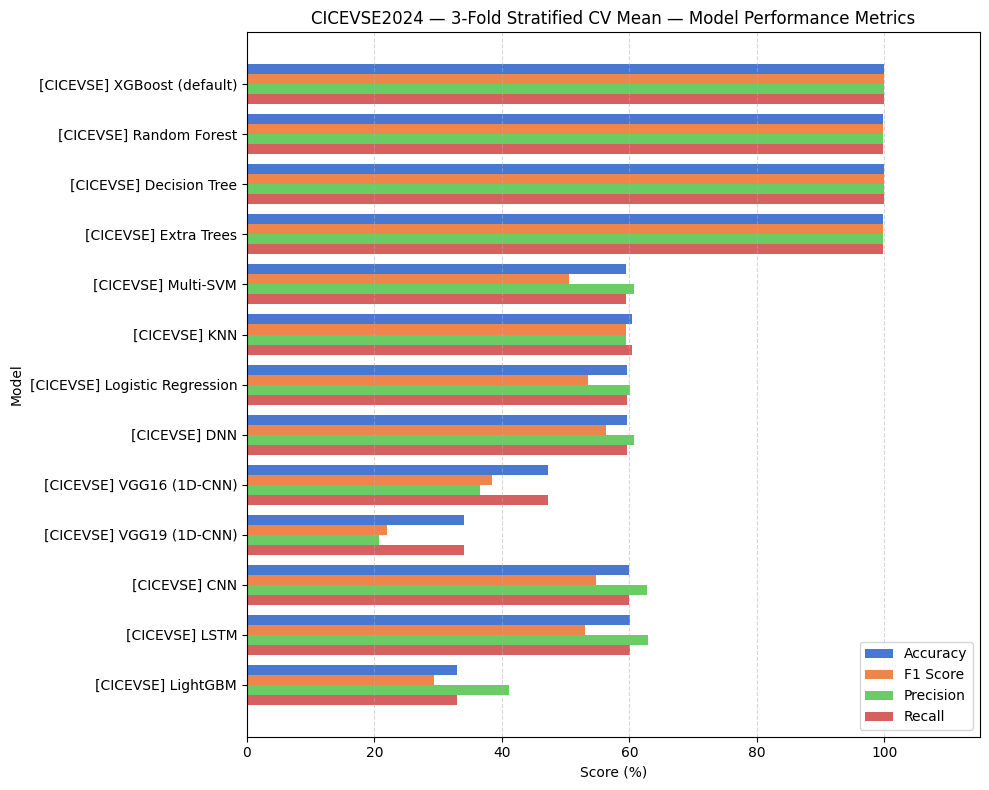

In [55]:
names     = [r.model_name for r in results_cicevse]
acc       = [r.accuracy   * 100 for r in results_cicevse]
f1        = [r.f1_score   * 100 for r in results_cicevse]
precision = [r.precision  * 100 for r in results_cicevse]
recall    = [r.recall     * 100 for r in results_cicevse]

metrics      = [acc, f1, precision, recall]
metric_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
colors       = sns.color_palette('muted', 4)

y      = np.arange(len(names))
height = 0.2

fig, ax = plt.subplots(figsize=(10, 8))
for i, (vals, label, color) in enumerate(zip(metrics, metric_names, colors)):
    ax.barh(y + i * height, vals, height, label=label, color=color)

ax.set_ylabel('Model')
ax.set_xlabel('Score (%)')
ax.set_title('CICEVSE2024 — 3-Fold Stratified CV Mean — Model Performance Metrics')
ax.set_yticks(y + height * (len(metrics) - 1) / 2)
ax.set_yticklabels(names)
ax.set_xlim(0, 115)
ax.invert_yaxis()
ax.legend()
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

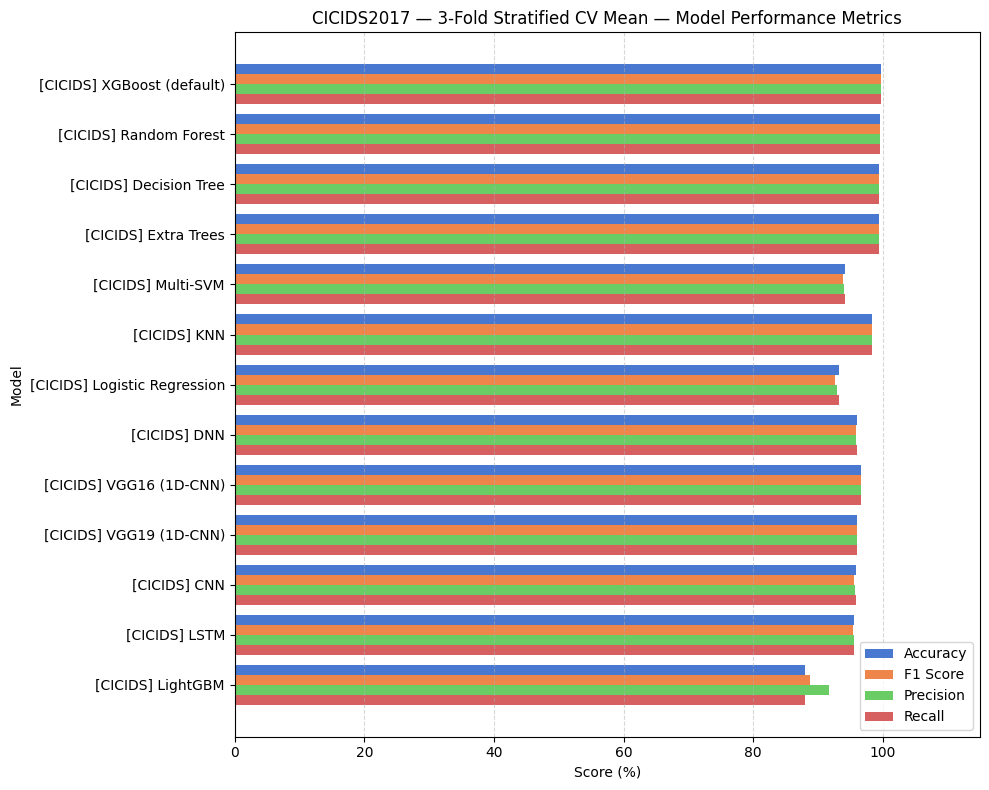

In [56]:
names_cicids = [r.model_name for r in results_cicids]
acc       = [r.accuracy   * 100 for r in results_cicids]
f1        = [r.f1_score   * 100 for r in results_cicids]
precision = [r.precision  * 100 for r in results_cicids]
recall    = [r.recall     * 100 for r in results_cicids]

metrics      = [acc, f1, precision, recall]
metric_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
colors       = sns.color_palette('muted', 4)

y      = np.arange(len(names_cicids))
height = 0.2

fig, ax = plt.subplots(figsize=(10, 8))
for i, (vals, label, color) in enumerate(zip(metrics, metric_names, colors)):
    ax.barh(y + i * height, vals, height, label=label, color=color)

ax.set_ylabel('Model')
ax.set_xlabel('Score (%)')
ax.set_title('CICIDS2017 — 3-Fold Stratified CV Mean — Model Performance Metrics')
ax.set_yticks(y + height * (len(metrics) - 1) / 2)
ax.set_yticklabels(names_cicids)
ax.set_xlim(0, 115)
ax.invert_yaxis()
ax.legend()
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

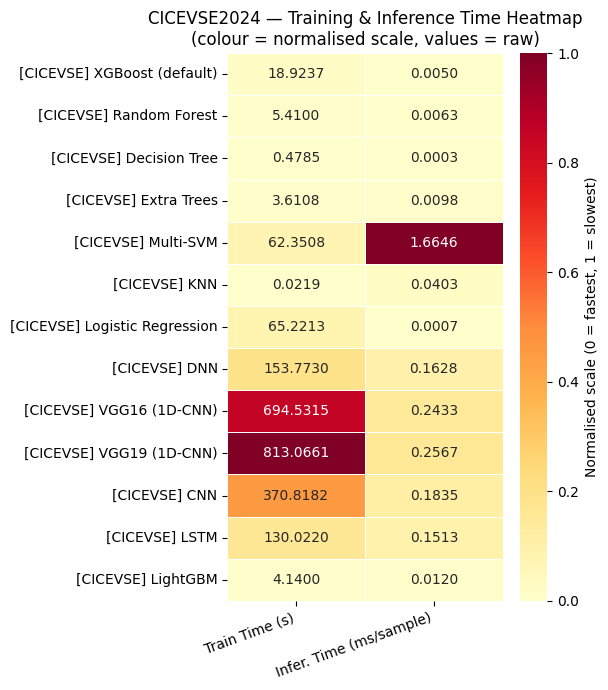

In [57]:
# Heatmap: Training time & Inference time
time_df = pd.DataFrame({
    "Train Time (s)":         [r.training_time_s   for r in results_cicevse],
    "Infer. Time (ms/sample)":[r.inference_time_ms for r in results_cicevse],
}, index=[r.model_name for r in results_cicevse])

# Min-max normalise each column for colour scale
norm_df = (time_df - time_df.min()) / (time_df.max() - time_df.min())

# Annotation strings showing raw values
annot = time_df.map(lambda v: f"{v:.4f}")

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(
    norm_df, annot=annot, fmt='', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Normalised scale (0 = fastest, 1 = slowest)'}
)
ax.set_title("CICEVSE2024 — Training & Inference Time Heatmap\n(colour = normalised scale, values = raw)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()

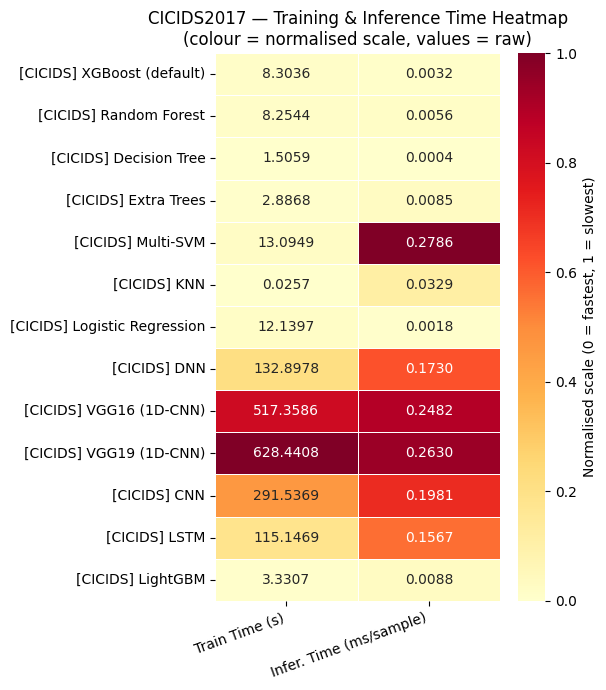

In [58]:
# Heatmap: Training time & Inference time (CICIDS2017)
time_df_cicids = pd.DataFrame({
    "Train Time (s)":         [r.training_time_s   for r in results_cicids],
    "Infer. Time (ms/sample)":[r.inference_time_ms for r in results_cicids],
}, index=[r.model_name for r in results_cicids])

# Min-max normalise each column for colour scale
norm_df = (time_df_cicids - time_df_cicids.min()) / (time_df_cicids.max() - time_df_cicids.min())

# Annotation strings showing raw values
annot = time_df_cicids.map(lambda v: f"{v:.4f}")

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(
    norm_df, annot=annot, fmt='', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Normalised scale (0 = fastest, 1 = slowest)'}
)
ax.set_title("CICIDS2017 — Training & Inference Time Heatmap\n(colour = normalised scale, values = raw)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()